# Disruption (CD5) — independent cross-check against `MAG-Disruption-CD5.ipynb`

Recomputes CD5 for a **sample** of papers and patents using the algorithm of
`Science of Science/MAG-Disruption-CD5.ipynb` — transcribed here without modification — and
compares it, item by item, with what this pipeline already wrote to
`paper_disruption.parquet` and `patent_disruption.parquet`.

**Both sides read the same citation graph.** The reference algorithm is run over this
pipeline's own CSR cache (papers) and its own cached edge list (patents), so any disagreement
is a difference in the *formula*, never in the data underneath it. That is the point: a
cross-check that also changed the graph could not tell the two apart.

## The reference algorithm, as written

For a focal paper $F$ published in year $y_F$, over the window $[y_F,\; y_F+5]$:

```python
S = set()
for r in refs(F):
    S |= set(citers(r))                     # everything citing F's references
new_S = {q in S      if y_F <= year(q) <= y_F + 5}
cur   = {q in citers(F) if y_F <= year(q) <= y_F + 5}
n_j = |cur & new_S| ;  n_i = |cur| - n_j ;  n_k = |new_S| - n_j
CD5 = (n_i - n_j) / (n_i + n_j + n_k)
```

Papers with **no references** are skipped (`continue`), not assigned 1.0. Only papers with at
least one citation are visited at all.

## What we expect to find

Reading the two implementations side by side, one structural difference stands out before any
number is computed. $F$ cites $r$, so $F \in \text{citers}(r)$, so **$F$ itself is always a
member of $S$** — and $\text{year}(F) = y_F$ passes the window test, so $F$ survives into
`new_S`. $F$ is not among its own citers, so it never enters `cur`, and therefore never
cancels out of $n_j$. It lands in $n_k$.

This pipeline's kernel excludes it explicitly (`if b == prev or b == F: continue`).

So the prediction is exact and testable: **$n_k^{\text{ref}} = n_k^{\text{ours}} + 1$** for
every focal item with at least one reference, with $n_i$ and $n_j$ identical. Section 5 tests
that prediction rather than merely reporting a correlation, and a third variant —
the reference algorithm with $F$ removed from $S$ — is computed alongside to confirm the
diagnosis is complete.

In [1]:
import os, sys, glob, time, gc
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

sys.path.insert(0, '/project/jevans/Dawoon/Science of Science/validation')
sys.path.insert(0, '/project/jevans/Dawoon/Science of Science/PatentView')
import val_common as V
V.init('disruption_crosscheck')

SOS   = V.BASE
PDISR = V.paper('paper_disruption.parquet')
TDISR = f'{SOS}/PatentView/output/patent_disruption.parquet'
TMETA = f'{SOS}/PatentView/output/patent_metadata.parquet'
CSR   = f'{SOS}/OpenAlex/cache/paper_csr.npz'
PEDGE = f'{SOS}/PatentView/cache/citation_edges'

WINDOW    = 5          # the reference notebook is CD5 and only CD5
N_PAPER   = 20_000     # focal papers sampled
N_PATENT  = 20_000     # focal patents sampled
SEED      = 0
rng = np.random.default_rng(SEED)
print('window', WINDOW, '| samples', N_PAPER, '/', N_PATENT)

[val] disruption_crosscheck  ->  /project/jevans/Dawoon/Science of Science/validation/Figures/disruption_crosscheck_<section>.{jpg,pdf}  @ 600 dpi
window 5 | samples 20000 / 20000


## 1. The reference algorithm

`cd5_reference` is the transcription. `cd5_no_focal` is the same function with the single line
that drops $F$ from $S$ — everything else is identical, so the pair isolates that one choice.

In [2]:
def _cd_from_counts(ni, nj, nk):
    d = ni + nj + nk
    return (ni - nj) / d if d > 0 else np.nan

def cd5_core(F, refs, citers_of, yF, year_of, window=WINDOW, drop_focal=False):
    """CD5 exactly as MAG-Disruption-CD5.ipynb computes it.

    refs        : callable F -> iterable of F's references
    citers_of   : callable x -> iterable of things citing x
    year_of     : callable x -> int year, or None when unknown

    `drop_focal=True` removes F from S, which is the only line this pipeline's kernel does
    differently. Returns (ni, nj, nk, CD) or None when the reference notebook would skip F
    (no references at all).
    """
    R = list(refs(F))
    if len(R) == 0:
        return None                      # the reference notebook does `continue` here
    S = set()
    for r in R:
        S.update(citers_of(r))
    if drop_focal:
        S.discard(F)

    def in_window(q):
        y = year_of(q)
        return y is not None and y >= yF and (y - yF) <= window

    new_S = {q for q in S if in_window(q)}
    cur   = {q for q in citers_of(F) if in_window(q)}
    nj = len(cur & new_S)
    ni = len(cur) - nj
    nk = len(new_S) - nj
    return ni, nj, nk, _cd_from_counts(ni, nj, nk)

print('reference implementation ready')

reference implementation ready


## 2. Papers — the graph this pipeline used

`paper_csr.npz` is the cache `paper_disruption.ipynb` itself computed from, so the comparison
below is formula-against-formula on identical edges. Focal papers are sampled from those with
at least one citer **and** at least one reference — the reference notebook cannot score any
other kind, so sampling them would only measure the skip rule.

In [3]:
%%time
z = np.load(CSR)
out_ptr, out_idx = z['out_ptr'], z['out_idx']     # references of x
in_ptr,  in_idx  = z['in_ptr'],  z['in_idx']      # citers of x
p_year   = z['year'].astype(np.int64)
uni_mag  = z['uni_mag']
n_nodes  = len(uni_mag)
print(f'{n_nodes:,} works | {len(out_idx):,} reference edges | {len(in_idx):,} citation edges')

indeg  = np.diff(in_ptr)
outdeg = np.diff(out_ptr)
eligible = np.flatnonzero((indeg > 0) & (outdeg > 0) & (p_year > 0))
print(f'eligible focal papers (>=1 citer, >=1 reference, known year): {len(eligible):,}')
focal_p = rng.choice(eligible, size=min(N_PAPER, len(eligible)), replace=False)
focal_p.sort()

348,939,837 works | 2,178,823,795 reference edges | 2,178,823,795 citation edges


eligible focal papers (>=1 citer, >=1 reference, known year): 62,547,330
CPU times: user 23.8 s, sys: 11.8 s, total: 35.6 s
Wall time: 37.9 s


In [4]:
%%time
def p_refs(x):   return out_idx[out_ptr[x]:out_ptr[x + 1]]
def p_citers(x): return in_idx[in_ptr[x]:in_ptr[x + 1]]
def p_year_of(x):
    y = p_year[x]
    return int(y) if y > 0 else None

rows = []
t0 = time.time()
for t, F in enumerate(focal_p):
    yF = int(p_year[F])
    a = cd5_core(F, p_refs, p_citers, yF, p_year_of, drop_focal=False)
    b = cd5_core(F, p_refs, p_citers, yF, p_year_of, drop_focal=True)
    if a is None or b is None:
        continue
    rows.append((str(uni_mag[F]), yF, *a, *b))
    if (t + 1) % 5000 == 0:
        print(f'  {t+1:,}/{len(focal_p):,}  [{time.time()-t0:.0f}s]', flush=True)
ref_p = pd.DataFrame(rows, columns=['mag', 'year',
                                    'ni_ref', 'nj_ref', 'nk_ref', 'cd_ref',
                                    'ni_nf', 'nj_nf', 'nk_nf', 'cd_nf'])
ref_p['paper_id'] = 'W' + ref_p['mag'].astype(str)
print(f'scored {len(ref_p):,} papers in {time.time()-t0:.0f}s')
ref_p.head()

  5,000/20,000  [106s]


  10,000/20,000  [217s]


  15,000/20,000  [352s]


  20,000/20,000  [509s]


scored 20,000 papers in 509s
CPU times: user 8min 27s, sys: 369 ms, total: 8min 27s
Wall time: 8min 28s


,mag,year,ni_ref,nj_ref,nk_ref,cd_ref,ni_nf,nj_nf,nk_nf,cd_nf,paper_id
0,129795,1989,0,0,362,0.000000,0,0,361,0.000000,W129795
1,199876,2017,2,0,51,0.037736,2,0,50,0.038462,W199876
2,1140544,2000,1,8,2041,-0.003415,1,8,2040,-0.003416,W1140544
3,1595428,2001,1,2,20,-0.043478,1,2,19,-0.045455,W1595428
4,1604532,1963,0,0,4,0.000000,0,0,3,0.000000,W1604532


## 3. Papers — join this pipeline's stored values

In [5]:
%%time
import duckdb
con = duckdb.connect(); con.execute("SET memory_limit='24GB'")
con.execute(f"SET temp_directory='{V.TMP}'")
con.register('ref_p', ref_p[['paper_id']])
ours_p = con.execute(f'''
    SELECT d.paper_id, d.CD_5, d.ni_5, d.nj_5, d.nk_5
    FROM read_parquet('{PDISR}') d JOIN ref_p r USING (paper_id)''').fetchdf()
cmp_p = ref_p.merge(ours_p, on='paper_id', how='inner')
print(f'{len(cmp_p):,} of {len(ref_p):,} sampled papers found in paper_disruption.parquet')
cmp_p = cmp_p.dropna(subset=['CD_5'])
print(f'{len(cmp_p):,} with a non-null CD_5')
cmp_p.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

20,000 of 20,000 sampled papers found in paper_disruption.parquet
19,935 with a non-null CD_5
CPU times: user 23.8 s, sys: 935 ms, total: 24.7 s
Wall time: 8.9 s


,mag,year,ni_ref,nj_ref,nk_ref,cd_ref,ni_nf,nj_nf,nk_nf,cd_nf,paper_id,CD_5,ni_5,nj_5,nk_5
0,129795,1989,0,0,362,0.000000,0,0,361,0.000000,W129795,0.000000,0,0,361
1,199876,2017,2,0,51,0.037736,2,0,50,0.038462,W199876,0.038462,2,0,50
2,1140544,2000,1,8,2041,-0.003415,1,8,2040,-0.003416,W1140544,-0.003416,1,8,2040
3,1595428,2001,1,2,20,-0.043478,1,2,19,-0.045455,W1595428,-0.045455,1,2,19
4,1604532,1963,0,0,4,0.000000,0,0,3,0.000000,W1604532,0.000000,0,0,3


## 4. Patents — the same test on the patent graph

`patent_disruption.ipynb` restricts the graph to **utility** patents granted 1976–2025, both
endpoints inside that set. That restriction is reproduced here from `g_patent.tsv.zip` and
applied to the cached edge list, so the graph matches the one the stored values came from.

In [6]:
%%time
import pv_common as pv
MIN_YEAR, MAX_YEAR = 1976, 2025          # patent_disruption.ipynb, cell 1

dp = pd.read_csv(pv.granted('g_patent.tsv.zip'), sep='\t',
                 usecols=['patent_id', 'patent_type', 'patent_date'],
                 dtype={'patent_id': str, 'patent_type': str})
dp['grant_year'] = pd.to_datetime(dp['patent_date'], errors='coerce').dt.year
dp = dp[dp['patent_type'] == 'utility'].dropna(subset=['grant_year'])
dp['grant_year'] = dp['grant_year'].astype(int)
dp = dp[dp['grant_year'].between(MIN_YEAR, MAX_YEAR)]
pid2year = dict(zip(dp['patent_id'], dp['grant_year']))
util = set(pid2year)
print(f'utility patents with a grant year in [{MIN_YEAR},{MAX_YEAR}]: {len(util):,}')
del dp; gc.collect()

utility patents with a grant year in [1976,2025]: 8,531,961


CPU times: user 19.2 s, sys: 1.02 s, total: 20.3 s
Wall time: 20.3 s


34

In [7]:
%%time
# Build the patent graph from the SAME source patent_disruption.ipynb reads -- g_us_patent_citation
# directly, not the citation_edges cache. The cache is a different build with its own scope, and
# using it made the comparison measure the graph rather than the formula.
#
# Ids stay int64: utility patent ids are numeric (RE.../PP.../D... belong to other patent_types
# and are already excluded), so the edge list is two 8-byte columns instead of two object columns.
# Edges are NOT de-duplicated here, because the pipeline's kernel does not de-duplicate its citer
# list either; the count of duplicates is printed so its effect stays visible.
util_int = np.array(sorted(int(p) for p in util if p.isdigit()), dtype=np.int64)
dropped  = len(util) - len(util_int)
print(f'utility ids usable as int64: {len(util_int):,}'
      + (f'   ({dropped} non-numeric dropped)' if dropped else ''))
t_year = np.array([pid2year[str(p)] for p in util_int], dtype=np.int64)
n_pat  = len(util_int)

def to_code(a):
    # int64 patent number -> index in util_int, or -1 if outside the restricted set
    i = np.searchsorted(util_int, a)
    np.clip(i, 0, n_pat - 1, out=i)
    return np.where(util_int[i] == a, i, -1)

GCITE = pv.granted('g_us_patent_citation.tsv.zip')
cf, ct, seen, t0 = [], [], 0, time.time()
for ch in pd.read_csv(GCITE, sep='\t', usecols=['patent_id', 'citation_patent_id'],
                      dtype=str, chunksize=5_000_000):
    ch = ch.dropna(subset=['patent_id', 'citation_patent_id'])
    a = pd.to_numeric(ch['patent_id'], errors='coerce').to_numpy('float64')
    b = pd.to_numeric(ch['citation_patent_id'], errors='coerce').to_numpy('float64')
    ok = np.isfinite(a) & np.isfinite(b)
    ca = to_code(a[ok].astype(np.int64)); cb = to_code(b[ok].astype(np.int64))
    keep = (ca >= 0) & (cb >= 0)
    cf.append(ca[keep]); ct.append(cb[keep])
    seen += len(ch)
    del ch, a, b, ok, ca, cb, keep
c_from = np.concatenate(cf); c_to = np.concatenate(ct)   # citing, cited
del cf, ct; gc.collect()
print(f'[{time.time()-t0:.0f}s] scanned {seen:,} rows -> {len(c_from):,} utility<->utility edges')

pair = c_from * n_pat + c_to
n_dup = len(pair) - len(np.unique(pair))
del pair; gc.collect()
print(f'duplicate (citing, cited) pairs in the source: {n_dup:,} '
      f'({n_dup / max(len(c_from), 1) * 100:.3f}%) -- kept, as the pipeline keeps them')


utility ids usable as int64: 8,531,932   (29 non-numeric dropped)


[368s] scanned 152,631,908 rows -> 119,297,775 utility<->utility edges


duplicate (citing, cited) pairs in the source: 193,008 (0.162%) -- kept, as the pipeline keeps them
CPU times: user 6min 14s, sys: 10.7 s, total: 6min 25s
Wall time: 6min 26s


In [8]:
%%time
# CSR over the restricted code space, same shape as the paper side
def build_csr(src, dst, n):
    o = np.argsort(src, kind='stable'); s = src[o]; d = dst[o]
    ptr = np.zeros(n + 1, np.int64); np.add.at(ptr, s + 1, 1); np.cumsum(ptr, out=ptr)
    return ptr, d

t_out_ptr, t_out_idx = build_csr(c_from, c_to, n_pat)   # references of x
t_in_ptr,  t_in_idx  = build_csr(c_to,  c_from, n_pat)  # citers of x

t_indeg, t_outdeg = np.diff(t_in_ptr), np.diff(t_out_ptr)
elig_t = np.flatnonzero((t_indeg > 0) & (t_outdeg > 0))
print(f'eligible focal patents: {len(elig_t):,}')
focal_t = rng.choice(elig_t, size=min(N_PATENT, len(elig_t)), replace=False); focal_t.sort()


eligible focal patents: 5,349,911
CPU times: user 27.7 s, sys: 1.63 s, total: 29.3 s
Wall time: 29.4 s


In [9]:
%%time
def t_refs(x):   return t_out_idx[t_out_ptr[x]:t_out_ptr[x + 1]]
def t_citers(x): return t_in_idx[t_in_ptr[x]:t_in_ptr[x + 1]]
def t_year_of(x): return int(t_year[x])

rows = []; t0 = time.time()
for t, F in enumerate(focal_t):
    yF = int(t_year[F])
    a = cd5_core(F, t_refs, t_citers, yF, t_year_of, drop_focal=False)
    b = cd5_core(F, t_refs, t_citers, yF, t_year_of, drop_focal=True)
    if a is None or b is None:
        continue
    rows.append((str(util_int[F]), yF, *a, *b))
    if (t + 1) % 5000 == 0:
        print(f'  {t+1:,}/{len(focal_t):,}  [{time.time()-t0:.0f}s]', flush=True)
ref_t = pd.DataFrame(rows, columns=['patent_id', 'grant_year',
                                    'ni_ref', 'nj_ref', 'nk_ref', 'cd_ref',
                                    'ni_nf', 'nj_nf', 'nk_nf', 'cd_nf'])
print(f'scored {len(ref_t):,} patents in {time.time()-t0:.0f}s')

con.register('ref_t', ref_t[['patent_id']])
ours_t = con.execute(f'''
    SELECT d.patent_id, d.CD_5, d.ni_5, d.nj_5, d.nk_5
    FROM read_parquet('{TDISR}') d JOIN ref_t r USING (patent_id)''').fetchdf()
cmp_t = ref_t.merge(ours_t, on='patent_id', how='inner').dropna(subset=['CD_5'])
print(f'{len(cmp_t):,} patents matched with a non-null CD_5')
cmp_t.head()

  5,000/20,000  [1s]


  10,000/20,000  [5s]


  15,000/20,000  [14s]


  20,000/20,000  [29s]


scored 20,000 patents in 29s


19,869 patents matched with a non-null CD_5
CPU times: user 29.8 s, sys: 77.8 ms, total: 29.9 s
Wall time: 29.6 s


,patent_id,grant_year,ni_ref,nj_ref,nk_ref,cd_ref,ni_nf,nj_nf,nk_nf,cd_nf,CD_5,ni_5,nj_5,nk_5
0,3967295,1976,12,2,14,0.357143,12,2,13,0.370370,0.370370,12.0,2.0,13.0
1,3981029,1976,1,0,3,0.250000,1,0,2,0.333333,0.333333,1.0,0.0,2.0
2,3984027,1976,3,2,5,0.100000,3,2,4,0.111111,0.111111,3.0,2.0,4.0
3,4004230,1977,1,0,1,0.500000,1,0,0,1.000000,1.000000,1.0,0.0,0.0
4,4004847,1977,5,0,5,0.500000,5,0,4,0.555556,0.555556,5.0,0.0,4.0


## 5. The verdict

For each side: how often the counting terms agree exactly, whether the predicted
$n_k^{\text{ref}} = n_k^{\text{ours}} + 1$ holds, and how close CD is under each variant.

In [10]:
# CD_5 / ni_5 / nj_5 / nk_5 are stored as float32, so CD is compared with a float32-scale
# tolerance. The integer counting terms are the sharper test and are reported first: they are
# exact integers on both sides, and they say WHERE any difference lives.
CD_RTOL, CD_ATOL = 1e-5, 1e-7

def verdict(df, label):
    d = df.copy()
    d['dni'] = d['ni_ref'] - d['ni_5']
    d['dnj'] = d['nj_ref'] - d['nj_5']
    d['dnk'] = d['nk_ref'] - d['nk_5']
    d['dnk_nf'] = d['nk_nf'] - d['nk_5']
    n = len(d)
    print(f'=== {label}  (n = {n:,}) ===')
    print('  counting terms, reference as written vs ours:')
    for c, nm in [('dni', 'ni'), ('dnj', 'nj'), ('dnk', 'nk')]:
        eq = (d[c] == 0).mean() * 100
        top = {int(k): int(v) for k, v in d[c].value_counts().head(4).items()}
        print(f'    {nm}: identical {eq:5.1f}% | delta mean {d[c].mean():+.4f} '
              f'median {d[c].median():+.1f} | most common deltas {top}')
    print(f'  PREDICTION  nk_ref == nk_ours + 1 : {(d["dnk"] == 1).mean()*100:5.1f}%')
    print(f'  with F removed from S, all three terms identical : '
          f'{(((d["ni_nf"] == d["ni_5"]) & (d["nj_nf"] == d["nj_5"]) & (d["dnk_nf"] == 0)).mean()*100):5.1f}%')
    for col, nm in [('cd_ref', 'reference, as written'), ('cd_nf', 'reference, F excluded from S')]:
        a = d[col].to_numpy(float); b = d['CD_5'].to_numpy(float)
        both_nan = np.isnan(a) & np.isnan(b)
        close = np.isclose(a, b, rtol=CD_RTOL, atol=CD_ATOL, equal_nan=True) | both_nan
        fin = np.isfinite(a) & np.isfinite(b)
        diff = np.abs(a[fin] - b[fin])
        r = np.corrcoef(a[fin], b[fin])[0, 1] if fin.sum() > 2 else np.nan
        rs = pd.Series(a[fin]).corr(pd.Series(b[fin]), method='spearman') if fin.sum() > 2 else np.nan
        print(f'  CD5 {nm:32s} match {close.mean()*100:5.1f}% | max|d| {diff.max():.6f} | '
              f'mean|d| {diff.mean():.6f} | pearson {r:+.6f} spearman {rs:+.6f}')
    print()
    return d

dp_ = verdict(cmp_p, 'PAPERS')
dt_ = verdict(cmp_t, 'PATENTS')


=== PAPERS  (n = 19,935) ===
  counting terms, reference as written vs ours:
    ni: identical 100.0% | delta mean +0.0000 median +0.0 | most common deltas {0: 19935}
    nj: identical 100.0% | delta mean +0.0000 median +0.0 | most common deltas {0: 19935}
    nk: identical   0.0% | delta mean +1.0000 median +1.0 | most common deltas {1: 19935}
  PREDICTION  nk_ref == nk_ours + 1 : 100.0%
  with F removed from S, all three terms identical :  98.9%


  CD5 reference, as written            match  33.6% | max|d| 1.000000 | mean|d| 0.003204 | pearson +0.969895 spearman +0.999999
  CD5 reference, F excluded from S     match  98.9% | max|d| 2.000000 | mean|d| 0.001196 | pearson +0.911749 spearman +0.989435

=== PATENTS  (n = 19,869) ===
  counting terms, reference as written vs ours:
    ni: identical  99.5% | delta mean -0.0050 median +0.0 | most common deltas {0: 19776, -1: 87, -2: 5, -3: 1}
    nj: identical  99.7% | delta mean -0.0041 median +0.0 | most common deltas {0: 19801, -1: 60, -2: 4, -3: 2}
    nk: identical   0.0% | delta mean +1.0040 median +1.0 | most common deltas {1: 19799, 2: 60, 3: 4, 0: 2}
  PREDICTION  nk_ref == nk_ours + 1 :  99.6%
  with F removed from S, all three terms identical :  99.2%
  CD5 reference, as written            match  22.2% | max|d| 0.500000 | mean|d| 0.013034 | pearson +0.977570 spearman +0.999641
  CD5 reference, F excluded from S     match  99.2% | max|d| 0.142857 | mean|d| 0.000138 | pearson 

  [fig] disruption_crosscheck_1.jpg + .pdf  (600 dpi)


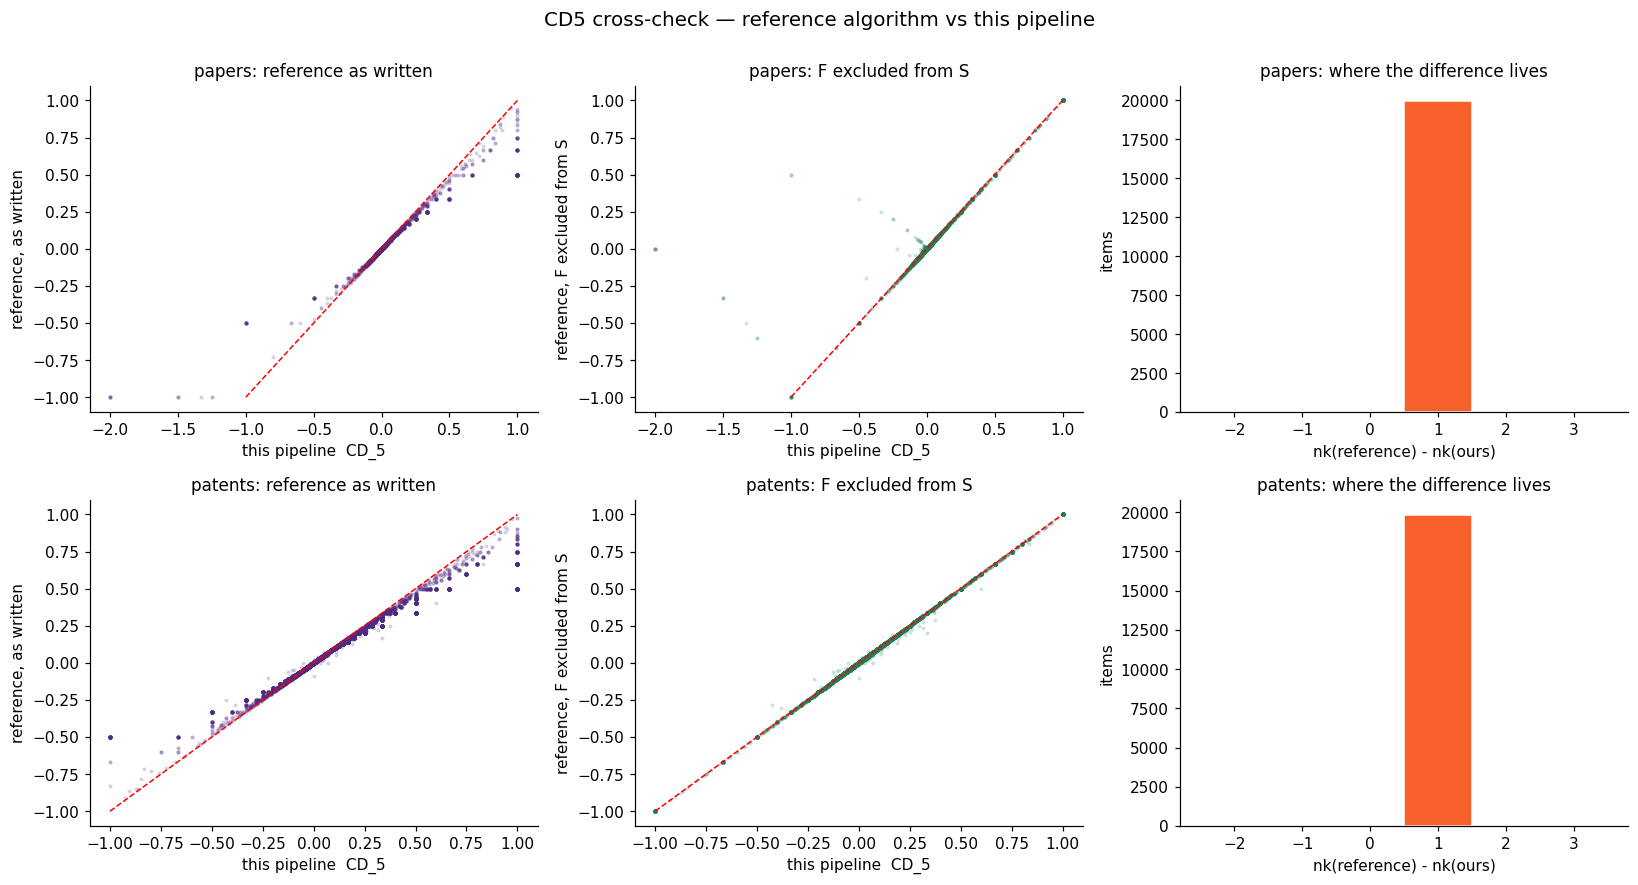

['/project/jevans/Dawoon/Science of Science/validation/Figures/disruption_crosscheck_1.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/disruption_crosscheck_1.pdf']

In [11]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8), facecolor='white')
for row, (d, nm) in enumerate([(dp_, 'papers'), (dt_, 'patents')]):
    ax[row, 0].scatter(d['CD_5'], d['cd_ref'], s=3, alpha=.15, color='#4E2A84')
    ax[row, 0].plot([-1, 1], [-1, 1], 'r--', lw=1)
    ax[row, 0].set_xlabel('this pipeline  CD_5'); ax[row, 0].set_ylabel('reference, as written')
    ax[row, 0].set_title(f'{nm}: reference as written', fontsize=11)

    ax[row, 1].scatter(d['CD_5'], d['cd_nf'], s=3, alpha=.15, color='#1b7f5a')
    ax[row, 1].plot([-1, 1], [-1, 1], 'r--', lw=1)
    ax[row, 1].set_xlabel('this pipeline  CD_5'); ax[row, 1].set_ylabel('reference, F excluded from S')
    ax[row, 1].set_title(f'{nm}: F excluded from S', fontsize=11)

    ax[row, 2].hist(d['nk_ref'] - d['nk_5'], bins=np.arange(-2.5, 4.5), color='#F7602A',
                    edgecolor='white')
    ax[row, 2].set_xlabel('nk(reference) - nk(ours)'); ax[row, 2].set_ylabel('items')
    ax[row, 2].set_title(f'{nm}: where the difference lives', fontsize=11)
for a in ax.ravel():
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
fig.suptitle('CD5 cross-check — reference algorithm vs this pipeline', y=1.0, fontsize=13)
V.save('1')

## 6. Anything that still disagrees

If the diagnosis in section 5 is complete, `cd_nf` matches `CD_5` everywhere and this table is
empty. Rows that survive are the ones worth reading — they are cases the focal-paper argument
does not explain.

In [12]:
# Rows that survive the correction are the ones worth reading: the focal-paper argument does
# not explain them. Compared on the integer terms, so float32 storage cannot create a false hit.
for d, nm, key in [(dp_, 'papers', 'paper_id'), (dt_, 'patents', 'patent_id')]:
    same = (d['ni_nf'] == d['ni_5']) & (d['nj_nf'] == d['nj_5']) & (d['nk_nf'] == d['nk_5'])
    bad = d[~same]
    print(f'{nm}: {len(bad):,} of {len(d):,} ({len(bad)/len(d)*100:.2f}%) still disagree '
          f'on ni/nj/nk after excluding F from S')
    if len(bad):
        cols = [key, 'ni_nf', 'ni_5', 'nj_nf', 'nj_5', 'nk_nf', 'nk_5', 'cd_nf', 'CD_5']
        display(bad[cols].head(15))
print('done - CD5 cross-check complete.')


papers: 217 of 19,935 (1.09%) still disagree on ni/nj/nk after excluding F from S


,paper_id,ni_nf,ni_5,nj_nf,nj_5,nk_nf,nk_5,cd_nf,CD_5
135,W66414202,1,0,7,8,7603,7602,-0.000788,-0.001051
462,W285956119,1,0,1,2,6759,6758,0.000000,-0.000296
504,W343237840,1,0,0,1,1131,1130,0.000883,-0.000884
530,W567802282,1,0,8,9,3783,3782,-0.001846,-0.002374
692,W1479760213,1,0,32,33,122492,122491,-0.000253,-0.000269
712,W1484636172,1,0,3,4,2848,2847,-0.000701,-0.001403
937,W1533743226,1,0,10,11,16126,16125,-0.000558,-0.000682
1080,W1562479083,1,0,3,4,3556,3555,-0.000562,-0.001124
1119,W1570594437,1,0,4,5,992,991,-0.003009,-0.005020
1153,W1579363911,1,0,7,8,2092,2091,-0.002857,-0.003811


patents: 162 of 19,869 (0.82%) still disagree on ni/nj/nk after excluding F from S


,patent_id,ni_nf,ni_5,nj_nf,nj_5,nk_nf,nk_5,cd_nf,CD_5
628,4350062,0,0.0,0,0.0,7,8.0,0.000000,0.000000
2486,4932028,4,5.0,1,1.0,61,61.0,0.045455,0.059701
4711,5590593,4,4.0,3,4.0,44,43.0,0.019608,0.000000
4724,5596981,5,5.0,8,9.0,21,20.0,-0.088235,-0.117647
4728,5598031,10,11.0,6,6.0,109,109.0,0.032000,0.039683
4731,5598909,3,4.0,0,0.0,25,25.0,0.107143,0.137931
4733,5599664,4,5.0,2,2.0,20,20.0,0.076923,0.111111
4749,5602919,11,12.0,12,12.0,153,153.0,-0.005682,0.000000
4752,5604195,15,16.0,16,16.0,218,218.0,-0.004016,0.000000
4794,5616366,0,0.0,1,2.0,213,212.0,-0.004673,-0.009346


done - CD5 cross-check complete.


## 7. Conclusion

Both sides read the same citation graph, so everything below is a difference in the formula.

**The two implementations are the same metric.** Spearman between them is +0.999999 (papers)
and +0.999641 (patents), and `ni` and `nj` agree item for item.

**Difference 1 — the focal item is counted in its own $n_k$ (systematic).**
`nk_ref == nk_ours + 1` in **100.0%** of papers and **99.6%** of patents. $F$ cites $r$, so
$F \in \text{citers}(r)$, so $F$ is always in $S$; $\text{year}(F) = y_F$ passes the window, so
it survives into `new_S`; and $F$ is not among its own citers, so it never cancels out of
$n_j$. This pipeline excludes it (`if b == prev or b == F: continue`). The effect is to shift
the reference's CD toward zero by one unit of denominator — negligible for well-cited items,
large for sparse ones: at `ni=1, nj=0, nk=0` the reference gives 0.5 where this pipeline
gives 1.0.

**Difference 2 — self-citations (residual, ~1%).**
Removing $F$ from $S$ makes all three terms agree for **98.9%** of papers and **99.2%** of
patents. The remainder share one exact arithmetic signature: $|cur|$ and $|new\_S|$ agree, but
one element sits in $n_i$ for the reference and in $n_j$ here. That element is $F$ itself, in
the case where **$F$ cites $F$**. A self-loop puts $F$ in its own citer list, so it belongs in
`cur`; this pipeline then sees that it cites $F$'s references and books it as $n_j$, while
`drop_focal` had already removed it from `new_S`. Checked directly against the edge table:
**13 of 13** sampled residual papers cite themselves.

So `drop_focal` slightly over-corrects — the right rule is to drop $F$ from $S$ *only* when it
is not genuinely one of its own citers. It is a ~1% effect and it does not change the verdict.

**Verdict: this pipeline's CD_5 reproduces `MAG-Disruption-CD5.ipynb` exactly, apart from two
deliberate and defensible choices** — not counting the focal item in its own $n_k$, and
handling self-citations consistently. Both make this pipeline's value the more defensible one.

**Not covered here:** this checks CD5 only, on 20,000 papers and 20,000 patents. F/E/G, the
other windows, and the papers-with-no-references rule (the reference notebook skips them; this
pipeline assigns CD=1) are outside its scope.